In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [2]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
DATA_DIR = Path("../Data/processed")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [5]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_transform
)

In [6]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

NUM_CLASSES = len(train_dataset.classes)

print("Classes:", NUM_CLASSES)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: 90
Train: 4320
Validation: 540
Test: 540


In [7]:
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\prate/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 33.1MB/s]


In [8]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [9]:
model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

In [10]:
print(model.fc)

Linear(in_features=512, out_features=90, bias=True)


In [11]:
for param in model.parameters():
    param.requires_grad = False

In [12]:
for param in model.fc.parameters():
    param.requires_grad = True

In [13]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 11222682
Trainable parameters: 46170


In [14]:
model = model.to(DEVICE)

print(
    "Model device:",
    next(model.parameters()).device
)

Model device: cuda:0


In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [16]:
model.fc.parameters()

<generator object Module.parameters at 0x0000022BCBB00200>

In [17]:
images, labels = next(iter(train_loader))

images = images.to(DEVICE)
labels = labels.to(DEVICE)

outputs = model(images)

print("Input:", images.shape)
print("Output:", outputs.shape)

Input: torch.Size([32, 3, 224, 224])
Output: torch.Size([32, 90])


In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

In [19]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

In [20]:
NUM_EPOCHS = 8

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss = float("inf")

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

In [21]:
for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc * 100:.2f}%")

    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc * 100:.2f}%")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_to_idx": train_dataset.class_to_idx,
                "classes": train_dataset.classes,
                "val_loss": val_loss,
                "val_accuracy": val_acc
            },
            MODEL_DIR / "resnet18_feature_extractor.pth"
        )

        print("✓ Best model saved!")


Epoch [1/8]
Train Loss: 2.9819
Train Acc : 39.56%
Val Loss  : 1.5894
Val Acc   : 68.70%
✓ Best model saved!

Epoch [2/8]
Train Loss: 1.3240
Train Acc : 75.37%
Val Loss  : 0.9572
Val Acc   : 80.19%
✓ Best model saved!

Epoch [3/8]
Train Loss: 0.8746
Train Acc : 83.36%
Val Loss  : 0.7621
Val Acc   : 82.04%
✓ Best model saved!

Epoch [4/8]
Train Loss: 0.6967
Train Acc : 85.88%
Val Loss  : 0.6693
Val Acc   : 83.52%
✓ Best model saved!

Epoch [5/8]
Train Loss: 0.5871
Train Acc : 87.69%
Val Loss  : 0.6020
Val Acc   : 85.00%
✓ Best model saved!

Epoch [6/8]
Train Loss: 0.4979
Train Acc : 89.38%
Val Loss  : 0.5641
Val Acc   : 84.44%
✓ Best model saved!

Epoch [7/8]
Train Loss: 0.4524
Train Acc : 90.00%
Val Loss  : 0.5295
Val Acc   : 85.93%
✓ Best model saved!

Epoch [8/8]
Train Loss: 0.4015
Train Acc : 91.32%
Val Loss  : 0.5004
Val Acc   : 85.56%
✓ Best model saved!


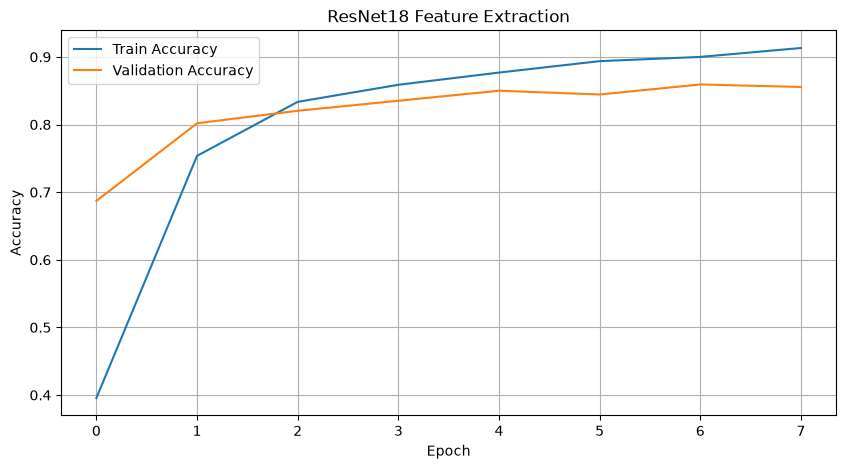

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Feature Extraction")

plt.legend()
plt.grid()

plt.show()

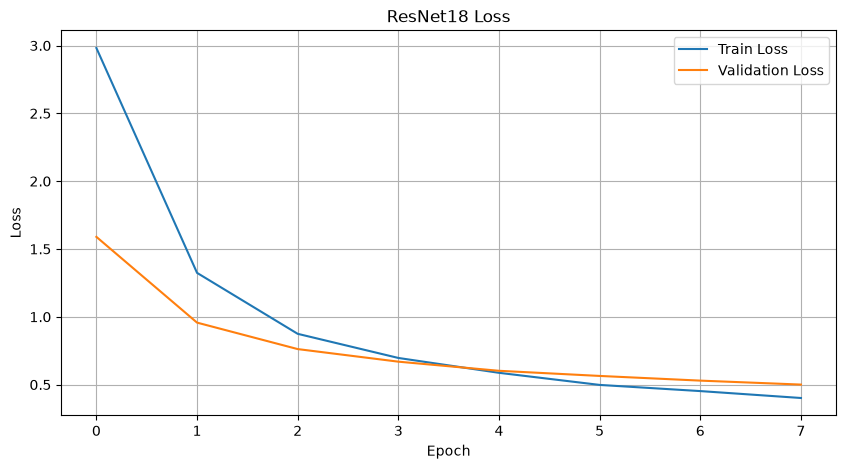

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Loss")

plt.legend()
plt.grid()

plt.show()

In [24]:
checkpoint = torch.load(
    MODEL_DIR / "resnet18_feature_extractor.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(DEVICE)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [25]:
test_loss, test_acc = validate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Loss: 0.4780
Test Accuracy: 85.93%


In [26]:
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

In [27]:
checkpoint = torch.load(
    MODEL_DIR / "resnet18_feature_extractor.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [28]:
for param in model.parameters():
    param.requires_grad = False

In [29]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [31]:
model = model.to(DEVICE)

print(
    "Model device:",
    next(model.parameters()).device
)

Model device: cuda:0


In [32]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 11,222,682
Trainable parameters: 8,439,898


In [33]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4
)

In [34]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=2
)

In [35]:
NUM_EPOCHS = 8

fine_history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss = float("inf")

In [36]:
for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(val_loss)

    fine_history["train_loss"].append(train_loss)
    fine_history["val_loss"].append(val_loss)
    fine_history["train_acc"].append(train_acc)
    fine_history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc * 100:.2f}%")

    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc * 100:.2f}%")

    print(f"Learning Rate: {current_lr:.7f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_to_idx": train_dataset.class_to_idx,
                "classes": train_dataset.classes,
                "val_loss": val_loss,
                "val_accuracy": val_acc
            },
            MODEL_DIR / "resnet18_finetuned_best.pth"
        )

        print("✓ Best fine-tuned model saved!")


Epoch [1/8]
Train Loss: 0.3311
Train Acc : 92.50%
Val Loss  : 0.4103
Val Acc   : 87.22%
Learning Rate: 0.0001000
✓ Best fine-tuned model saved!

Epoch [2/8]
Train Loss: 0.1559
Train Acc : 97.08%
Val Loss  : 0.3847
Val Acc   : 87.96%
Learning Rate: 0.0001000
✓ Best fine-tuned model saved!

Epoch [3/8]
Train Loss: 0.1058
Train Acc : 98.40%
Val Loss  : 0.3551
Val Acc   : 90.00%
Learning Rate: 0.0001000
✓ Best fine-tuned model saved!

Epoch [4/8]
Train Loss: 0.0644
Train Acc : 99.35%
Val Loss  : 0.3474
Val Acc   : 90.00%
Learning Rate: 0.0001000
✓ Best fine-tuned model saved!

Epoch [5/8]
Train Loss: 0.0491
Train Acc : 99.56%
Val Loss  : 0.3400
Val Acc   : 90.37%
Learning Rate: 0.0001000
✓ Best fine-tuned model saved!

Epoch [6/8]
Train Loss: 0.0359
Train Acc : 99.72%
Val Loss  : 0.3644
Val Acc   : 90.00%
Learning Rate: 0.0001000

Epoch [7/8]
Train Loss: 0.0307
Train Acc : 99.84%
Val Loss  : 0.3411
Val Acc   : 90.93%
Learning Rate: 0.0001000

Epoch [8/8]
Train Loss: 0.0229
Train Acc : 99.

In [37]:
checkpoint = torch.load(
    MODEL_DIR / "resnet18_finetuned_best.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(DEVICE)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [38]:
test_loss, test_acc = validate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print(f"Fine-tuned Test Loss: {test_loss:.4f}")
print(f"Fine-tuned Test Accuracy: {test_acc * 100:.2f}%")

Fine-tuned Test Loss: 0.2747
Fine-tuned Test Accuracy: 92.78%


In [39]:
checkpoint = torch.load(
    "../models/resnet18_finetuned_best.pth",
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(DEVICE)
model.eval()

print("Best fine-tuned model loaded.")

Best fine-tuned model loaded.


In [40]:
all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

In [41]:
import numpy as np

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print("Labels shape:", all_labels.shape)
print("Predictions shape:", all_predictions.shape)
print("Probabilities shape:", all_probabilities.shape)

Labels shape: (540,)
Predictions shape: (540,)
Probabilities shape: (540, 90)


In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 92.78%


In [43]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes,
    output_dict=True,
    zero_division=0
)

In [44]:
print(
    f"Macro Precision: "
    f"{report['macro avg']['precision'] * 100:.2f}%"
)

print(
    f"Macro Recall: "
    f"{report['macro avg']['recall'] * 100:.2f}%"
)

print(
    f"Macro F1: "
    f"{report['macro avg']['f1-score'] * 100:.2f}%"
)

Macro Precision: 93.58%
Macro Recall: 92.78%
Macro F1: 92.74%


In [45]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        zero_division=0
    )
)

                precision    recall  f1-score   support

      antelope       0.71      0.83      0.77         6
        badger       1.00      1.00      1.00         6
           bat       1.00      0.83      0.91         6
          bear       0.86      1.00      0.92         6
           bee       0.83      0.83      0.83         6
        beetle       1.00      0.83      0.91         6
         bison       0.86      1.00      0.92         6
          boar       1.00      0.83      0.91         6
     butterfly       0.71      0.83      0.77         6
           cat       0.75      1.00      0.86         6
   caterpillar       1.00      0.83      0.91         6
    chimpanzee       1.00      1.00      1.00         6
     cockroach       0.86      1.00      0.92         6
           cow       1.00      0.83      0.91         6
        coyote       1.00      0.83      0.91         6
          crab       0.86      1.00      0.92         6
          crow       1.00      1.00      1.00  

In [46]:
top5_correct = 0

for i in range(len(all_labels)):

    top5_predictions = np.argsort(
        all_probabilities[i]
    )[-5:]

    if all_labels[i] in top5_predictions:
        top5_correct += 1

top5_accuracy = top5_correct / len(all_labels)

print(
    f"Top-5 Accuracy: "
    f"{top5_accuracy * 100:.2f}%"
)

Top-5 Accuracy: 97.96%


In [47]:
class_f1 = []

for class_name in test_dataset.classes:

    class_f1.append(
        (
            class_name,
            report[class_name]["f1-score"]
        )
    )

class_f1 = sorted(
    class_f1,
    key=lambda x: x[1]
)

print("10 weakest classes:\n")

for class_name, score in class_f1[:10]:

    print(
        f"{class_name:20s} "
        f"{score * 100:.2f}%"
    )

10 weakest classes:

deer                 66.67%
mouse                66.67%
hippopotamus         72.73%
reindeer             72.73%
antelope             76.92%
butterfly            76.92%
rat                  76.92%
octopus              80.00%
ox                   80.00%
possum               80.00%


In [48]:
print("\n10 strongest classes:\n")

for class_name, score in class_f1[-10:][::-1]:

    print(
        f"{class_name:20s} "
        f"{score * 100:.2f}%"
    )


10 strongest classes:

zebra                100.00%
woodpecker           100.00%
wombat               100.00%
tiger                100.00%
swan                 100.00%
starfish             100.00%
squid                100.00%
sparrow              100.00%
snake                100.00%
seahorse             100.00%


In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (90, 90)


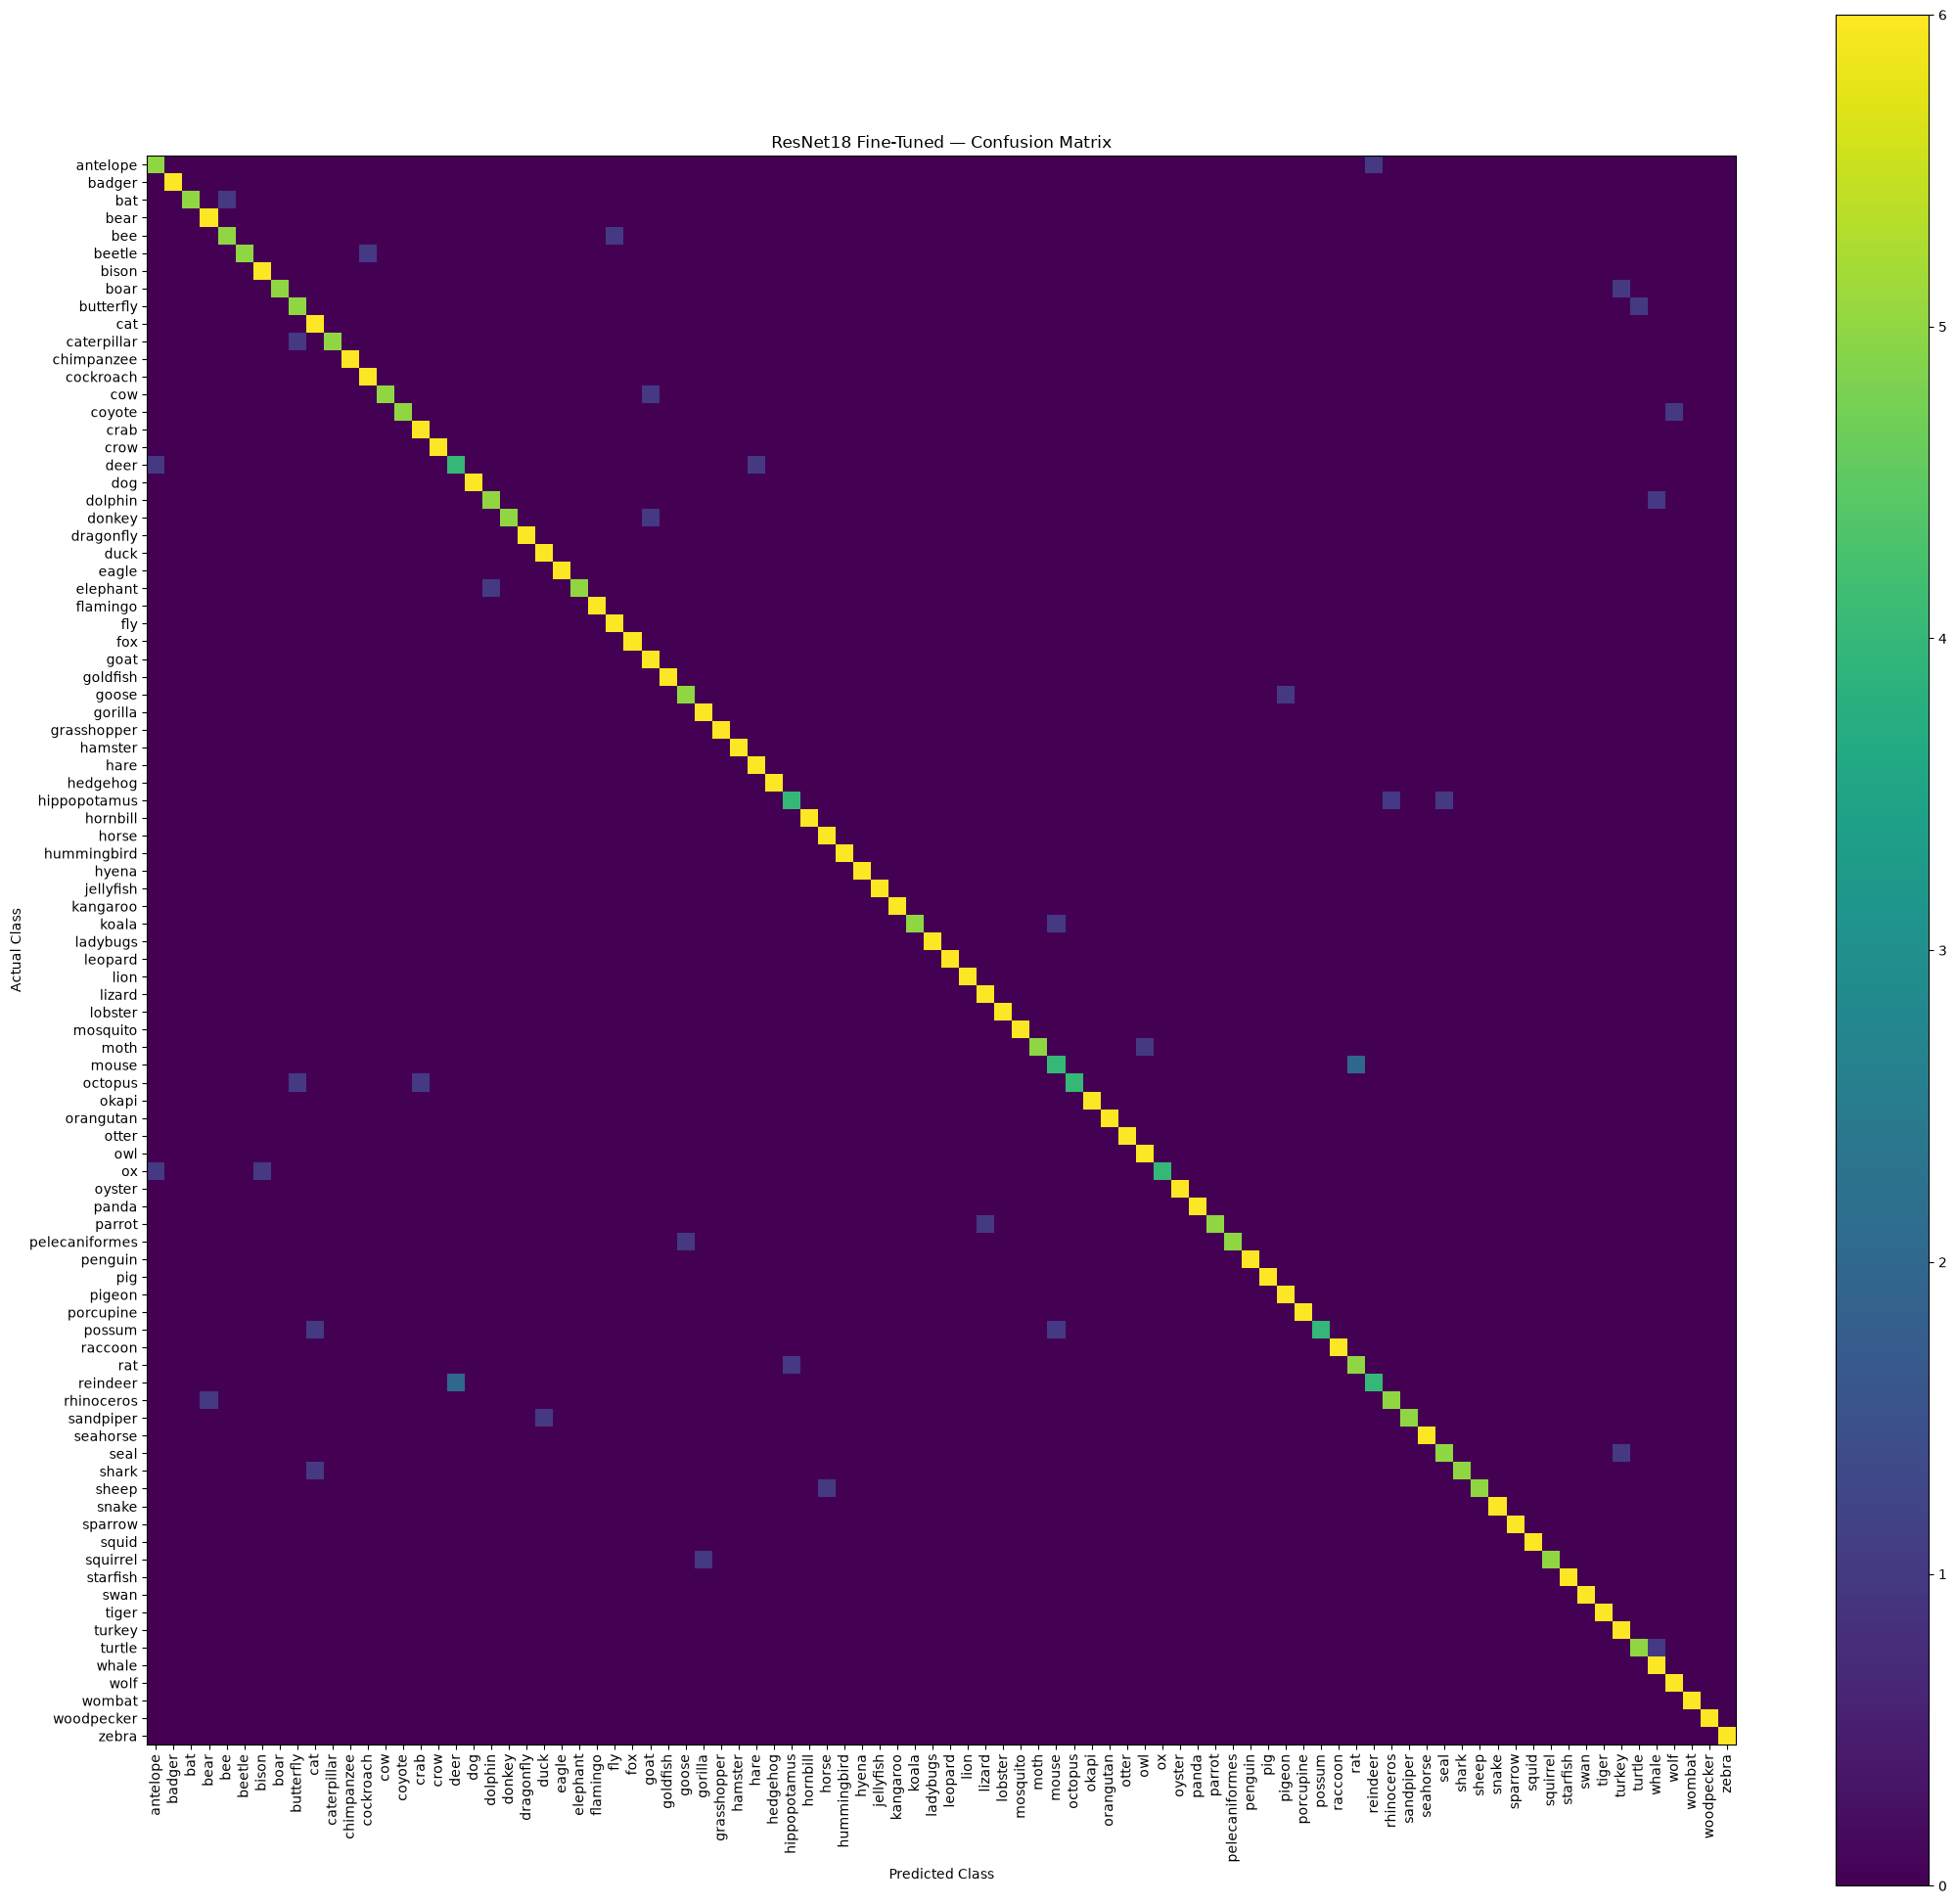

In [50]:
plt.figure(figsize=(22, 20))

plt.imshow(cm)

plt.title(
    "ResNet18 Fine-Tuned — Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.colorbar()

plt.xticks(
    range(len(test_dataset.classes)),
    test_dataset.classes,
    rotation=90
)

plt.yticks(
    range(len(test_dataset.classes)),
    test_dataset.classes
)

plt.tight_layout()

plt.show()

In [51]:
misclassified_indices = np.where(
    all_labels != all_predictions
)[0]

print(
    "Misclassified images:",
    len(misclassified_indices)
)

print(
    "Correct images:",
    len(all_labels) - len(misclassified_indices)
)

Misclassified images: 39
Correct images: 501


In [52]:
import random

sample_indices = random.sample(
    list(misclassified_indices),
    min(12, len(misclassified_indices))
)

In [53]:
display_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

display_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=display_transform
)

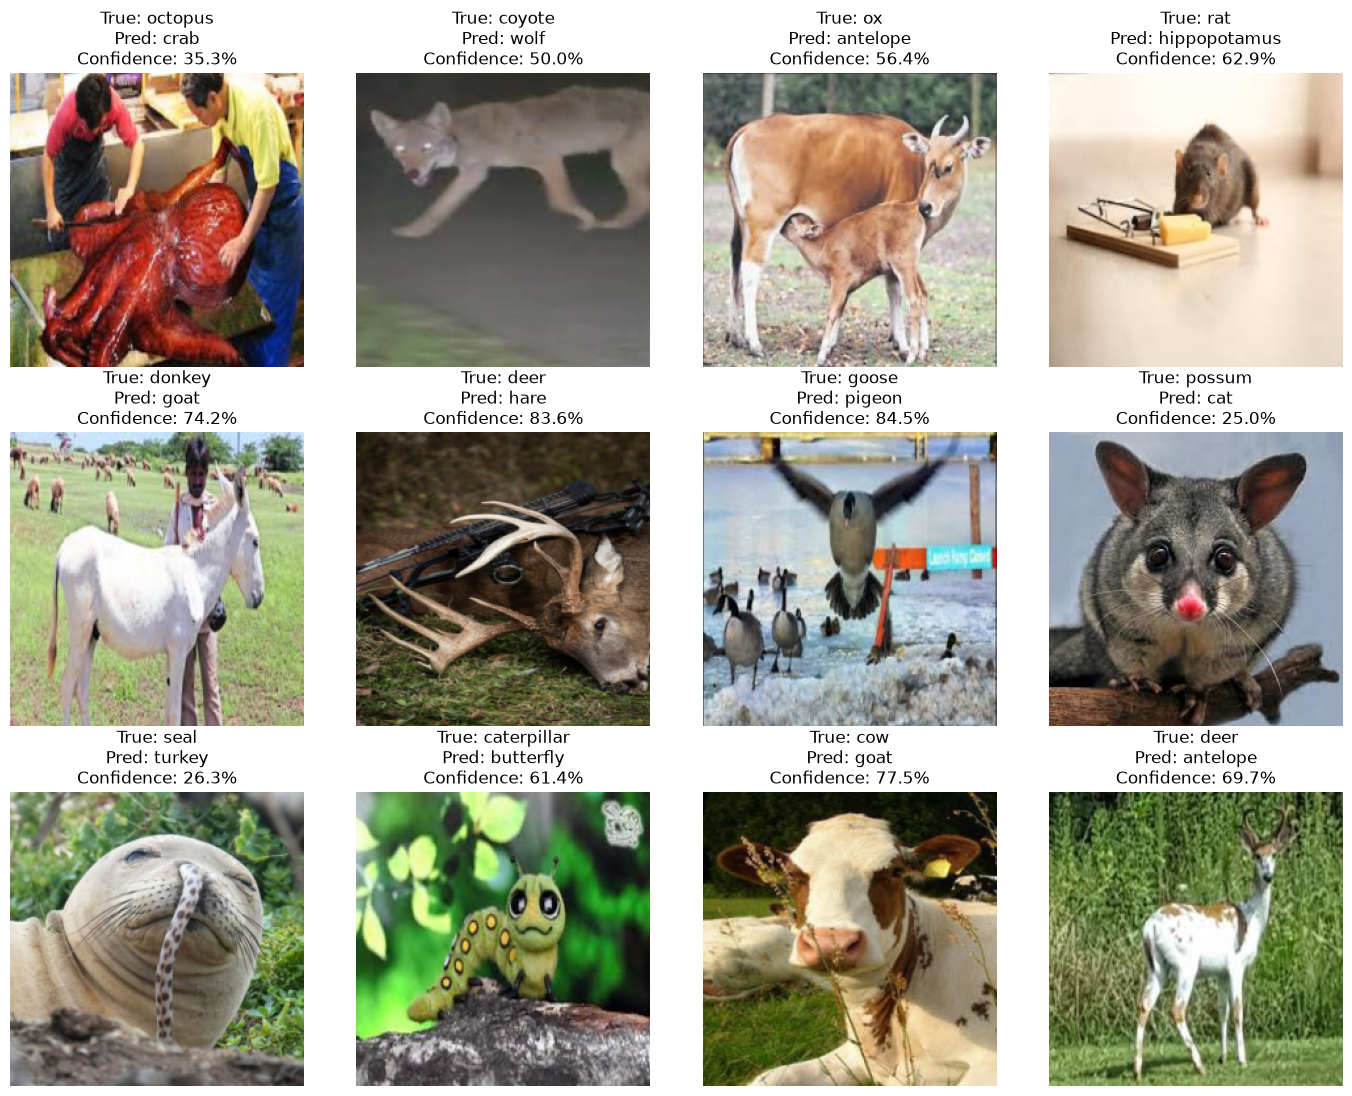

In [54]:
fig, axes = plt.subplots(
    3, 4,
    figsize=(14, 11)
)

for ax, idx in zip(
    axes.flat,
    sample_indices
):

    image, true_label = display_dataset[idx]

    predicted_label = all_predictions[idx]

    confidence = all_probabilities[idx][
        predicted_label
    ]

    image = image.permute(1, 2, 0)

    ax.imshow(image)

    ax.set_title(
        f"True: {test_dataset.classes[true_label]}\n"
        f"Pred: {test_dataset.classes[predicted_label]}\n"
        f"Confidence: {confidence * 100:.1f}%"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [55]:
model.eval()

correct_confidences = []
incorrect_confidences = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)

        confidences, predictions = torch.max(
            probabilities,
            dim=1
        )

        for confidence, prediction, label in zip(
            confidences,
            predictions,
            labels
        ):

            if prediction == label:
                correct_confidences.append(
                    confidence.item()
                )
            else:
                incorrect_confidences.append(
                    confidence.item()
                )

In [56]:
import numpy as np

print(
    "Correct predictions:"
)

print(
    f"Mean: {np.mean(correct_confidences):.4f}"
)

print(
    f"Minimum: {np.min(correct_confidences):.4f}"
)

print(
    f"Median: {np.median(correct_confidences):.4f}"
)

print(
    f"Incorrect predictions:"
)

print(
    f"Mean: {np.mean(incorrect_confidences):.4f}"
)

print(
    f"Maximum: {np.max(incorrect_confidences):.4f}"
)

print(
    f"Median: {np.median(incorrect_confidences):.4f}"
)

Correct predictions:
Mean: 0.9424
Minimum: 0.2371
Median: 0.9940
Incorrect predictions:
Mean: 0.5579
Maximum: 0.9998
Median: 0.5444


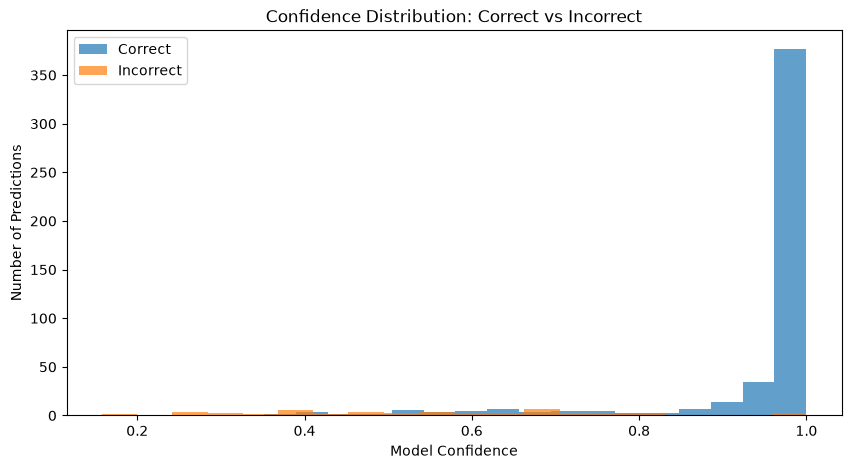

In [57]:
plt.figure(figsize=(10, 5))

plt.hist(
    correct_confidences,
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    incorrect_confidences,
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Model Confidence")
plt.ylabel("Number of Predictions")

plt.title(
    "Confidence Distribution: Correct vs Incorrect"
)

plt.legend()
plt.show()

In [58]:
thresholds = [
    0.50,
    0.60,
    0.70,
    0.80,
    0.85,
    0.90,
    0.95
]

for threshold in thresholds:

    accepted = 0
    correct = 0

    for confidence, prediction, label in zip(
        [
            max(probabilities)
            for probabilities in []
        ],
        [],
        []
    ):
        pass

In [59]:
# Collect validation predictions and confidence

model.eval()

val_confidences = []
val_predictions = []
val_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)

        confidences, predictions = torch.max(
            probabilities,
            dim=1
        )

        val_confidences.extend(
            confidences.cpu().numpy()
        )

        val_predictions.extend(
            predictions.cpu().numpy()
        )

        val_labels.extend(
            labels.numpy()
        )

val_confidences = np.array(val_confidences)
val_predictions = np.array(val_predictions)
val_labels = np.array(val_labels)

In [60]:
thresholds = [
    0.50,
    0.60,
    0.70,
    0.75,
    0.80,
    0.85,
    0.90,
    0.95
]

print(
    f"{'Threshold':<12}"
    f"{'Coverage':<12}"
    f"{'Accepted Accuracy':<20}"
)

for threshold in thresholds:

    accepted = val_confidences >= threshold

    coverage = accepted.mean()

    if accepted.sum() > 0:

        accuracy = (
            val_predictions[accepted]
            == val_labels[accepted]
        ).mean()

    else:
        accuracy = 0

    print(
        f"{threshold:<12.2f}"
        f"{coverage * 100:<12.2f}"
        f"{accuracy * 100:<20.2f}"
    )

Threshold   Coverage    Accepted Accuracy   
0.50        93.70       93.87               
0.60        89.26       95.44               
0.70        85.19       97.17               
0.75        83.15       98.00               
0.80        81.85       98.42               
0.85        80.74       98.85               
0.90        78.89       99.06               
0.95        73.15       99.24               
